<a href="https://colab.research.google.com/github/bonfito/GroupF/blob/GenerativeMethod/Notebookstask3_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
base = Path('/content/drive/MyDrive/Imaging')
print('Imaging/ esiste:', base.exists())
print('Contenuto Imaging/:', [p.name for p in base.iterdir()])

# Cerca le immagini della retina
pngs = list(base.rglob('*.png'))
print('\nPNG trovati in Imaging/:', len(pngs))
if pngs:
    print('Percorso esempio:', pngs[0])

Mounted at /content/drive
Imaging/ esiste: True
Contenuto Imaging/: ['Mayo', 'IPPy', 'weights', 'homework2-addestramento.ipynb', 'homework2.ipynb', 'project']

PNG trovati in Imaging/: 4162
Percorso esempio: /content/drive/MyDrive/Imaging/project/data/retina/retinal_data/images/retinal_003195.png


# Setup


In [2]:
import sys
from pathlib import Path

# Percorsi (Drive è già montato)
book_root   = Path('/content/drive/MyDrive/Imaging')
ipp_root    = book_root / 'IPPy'
data_root   = book_root / 'project' / 'data' / 'retina' / 'retinal_data' / 'images'
split_root  = book_root / 'project' / 'data' / 'retina_split'
weights_dir = book_root / 'project' / 'weights'
weights_dir.mkdir(parents=True, exist_ok=True)

# IPPy nel path
sys.path.append(str(ipp_root))

# Stub astra (operators.py fa import astra, ma usiamo solo Blurring)
import types
sys.modules['astra'] = types.ModuleType('astra')

# Import
import torch
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import operators
from utilities import gaussian_noise, get_device
from nn.diffusion import DiffusionUNet, EMA, cosine_beta_schedule, extract, denormalize_to_01

device = get_device()
print('Device:', device)
print('Immagini disponibili:', len(list(data_root.glob('*.png'))))

Device: cuda
Immagini disponibili: 4162


# Split in train val e test

In [3]:
import random
import shutil

random.seed(42)

all_imgs = sorted(data_root.glob('*.png'))
random.shuffle(all_imgs)

n_train, n_val = 3500, 330
splits = {
    'train': all_imgs[:n_train],
    'val':   all_imgs[n_train:n_train + n_val],
    'test':  all_imgs[n_train + n_val:],
}

for split, imgs in splits.items():
    dest = split_root / split
    if dest.exists() and len(list(dest.glob('*.png'))) == len(imgs):
        print(f'{split}: già presente ({len(imgs)} immagini)')
        continue
    dest.mkdir(parents=True, exist_ok=True)
    for img_path in imgs:
        shutil.copy(img_path, dest / img_path.name)
    print(f'{split}: {len(imgs)} immagini → {dest}')

train: 3500 immagini → /content/drive/MyDrive/Imaging/project/data/retina_split/train
val: 330 immagini → /content/drive/MyDrive/Imaging/project/data/retina_split/val
test: 332 immagini → /content/drive/MyDrive/Imaging/project/data/retina_split/test


# Class del dataset e operatore K

Le immagini vengono ridimensionate a 256x256 come da indicazioni del progetto.
Normalizzazione in [-1,1] perche Diffpir lavora in quel range.

In [4]:
class RetinaDataset(Dataset):
  def __init__(self, data_path, data_shape = 256):
    super().__init__()
    self.fname_list = sorted(Path(data_path).glob('*.png'))
    self.transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((data_shape, data_shape), antialias=True),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5)),
    ])

  def __len__(self):
    return len(self.fname_list)


  def __getitem__(self, idx):
    x = Image.open(self.fname_list[idx])
    return self.transform(x)

train_dataset = RetinaDataset(split_root / 'train', data_shape = 256)
test_dataset = RetinaDataset(split_root / 'test', data_shape = 256)
val_dataset = RetinaDataset(split_root / 'val', data_shape = 256)

train_loader = DataLoader(train_dataset, batch_size =8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle = False)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle = False)


print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')


K = operators.Blurring(
    img_shape=(256, 256),
    kernel_type='motion',
    kernel_size=9,
    motion_angle=45,
)
print('Operatore K: motion blur 45°, kernel 9')


Train: 3500 | Val: 330 | Test: 332
Operatore K: motion blur 45°, kernel 9


# Livelli di Rumore



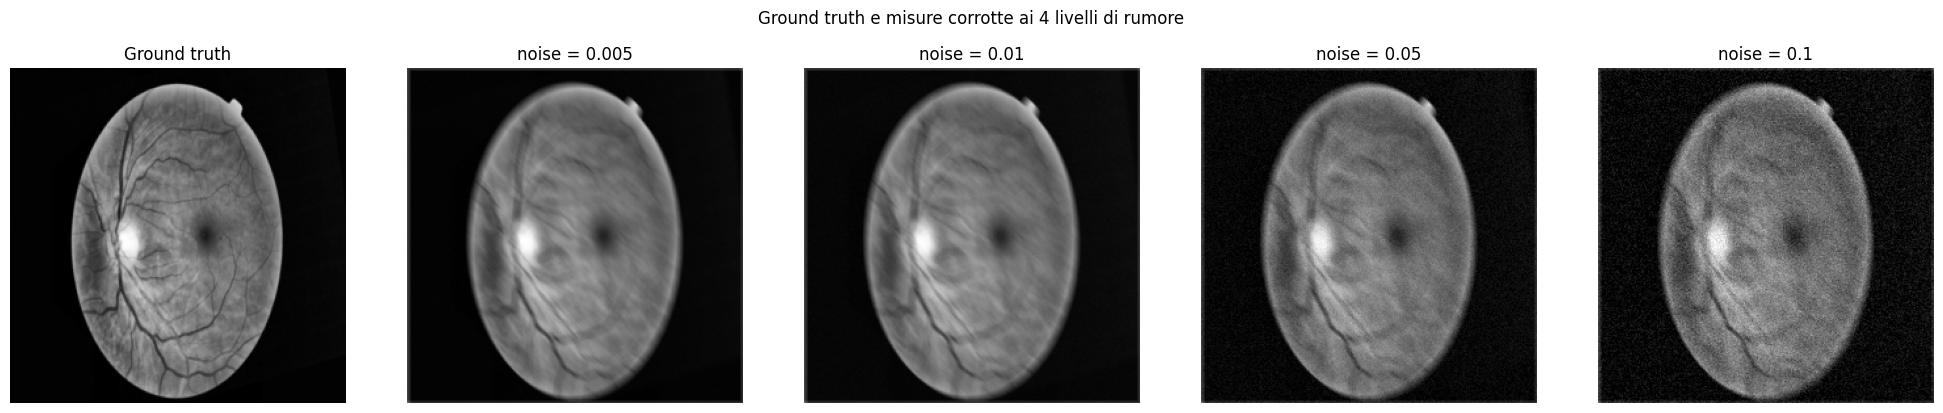

In [5]:
noise_levels = [0.005, 0.01, 0.05, 0.1]

with torch.no_grad():
    x_true = test_dataset[0].unsqueeze(0).to(device)

fig, axes = plt.subplots(1, len(noise_levels) + 1, figsize=(20, 4))

axes[0].imshow(denormalize_to_01(x_true).cpu().squeeze(), cmap='gray')
axes[0].set_title('Ground truth'); axes[0].axis('off')

for i, nl in enumerate(noise_levels):
    with torch.no_grad():
        y_delta = K(x_true) + nl * torch.randn_like(x_true)   # formula dei prof (EX6/EX7)
    axes[i+1].imshow(denormalize_to_01(y_delta).cpu().squeeze(), cmap='gray')
    axes[i+1].set_title(f'noise = {nl}'); axes[i+1].axis('off')

plt.suptitle('Ground truth e misure corrotte ai 4 livelli di rumore', y=1.02)
plt.tight_layout(); plt.show()